In [483]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.utils import shuffle

In [484]:
df : pd.DataFrame = pd.read_csv('full_dataset.csv')

In [485]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,48.0,2,492,2,16,4.0,1,1,1557,3,...,80,1,18,2,3,8,7,7,7,0
1,50.0,2,1322,1,28,3.0,1,1,1317,4,...,80,0,25,2,3,3,2,1,2,0
2,38.0,2,1495,1,4,2.0,3,1,1687,4,...,80,1,7,5,2,0,0,0,0,0
3,30.0,1,600,0,8,3.0,0,1,1747,3,...,80,1,6,0,2,4,2,1,2,1
4,36.0,1,541,2,3,4.0,3,1,481,1,...,80,1,16,2,3,13,9,1,12,0


In [486]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       473 non-null    float64
 1   BusinessTravel            474 non-null    int64  
 2   DailyRate                 474 non-null    int64  
 3   Department                474 non-null    int64  
 4   DistanceFromHome          474 non-null    int64  
 5   Education                 472 non-null    float64
 6   EducationField            474 non-null    int64  
 7   EmployeeCount             474 non-null    int64  
 8   EmployeeNumber            474 non-null    int64  
 9   EnvironmentSatisfaction   474 non-null    int64  
 10  Gender                    474 non-null    int64  
 11  HourlyRate                474 non-null    int64  
 12  JobInvolvement            474 non-null    int64  
 13  JobLevel                  474 non-null    int64  
 14  JobRole              

In [487]:
categoric_var=[]
numeric_var=[]
for i in df.columns:
    x = df[i].value_counts().count()
    if x < 10:
        categoric_var.append(i)
    else:
        numeric_var.append(i)

In [488]:
categoric_var

['BusinessTravel',
 'Department',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EnvironmentSatisfaction',
 'Gender',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'Over18',
 'OverTime',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'Attrition']

In [489]:
numeric_var

['Age',
 'DailyRate',
 'DistanceFromHome',
 'EmployeeNumber',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [490]:
columnsToDrop = ["EmployeeCount",
"EmployeeNumber",
"Over18",
"StandardHours"]

In [491]:
df.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition'],
      dtype='str')

In [492]:
df.drop(columnsToDrop,axis=1,inplace=True)

In [493]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,48.0,2,492,2,16,4.0,1,3,0,96,...,3,1,18,2,3,8,7,7,7,0
1,50.0,2,1322,1,28,3.0,1,4,0,43,...,2,0,25,2,3,3,2,1,2,0
2,38.0,2,1495,1,4,2.0,3,4,0,87,...,4,1,7,5,2,0,0,0,0,0
3,30.0,1,600,0,8,3.0,0,3,0,66,...,3,1,6,0,2,4,2,1,2,1
4,36.0,1,541,2,3,4.0,3,1,1,48,...,1,1,16,2,3,13,9,1,12,0


In [494]:
categoric_var=[]
numeric_var=[]
for i in df.columns:
    x = df[i].value_counts().count()
    if x < 10:
        categoric_var.append(i)
    else:
        numeric_var.append(i)

In [495]:
df.isna().sum().sort_values(ascending=False)

Education                   2
Age                         1
MonthlyRate                 0
YearsWithCurrManager        0
YearsSinceLastPromotion     0
YearsInCurrentRole          0
YearsAtCompany              0
WorkLifeBalance             0
TrainingTimesLastYear       0
TotalWorkingYears           0
StockOptionLevel            0
RelationshipSatisfaction    0
PerformanceRating           0
PercentSalaryHike           0
OverTime                    0
NumCompaniesWorked          0
MonthlyIncome               0
BusinessTravel              0
MaritalStatus               0
JobSatisfaction             0
JobRole                     0
JobLevel                    0
JobInvolvement              0
HourlyRate                  0
Gender                      0
EnvironmentSatisfaction     0
EducationField              0
DistanceFromHome            0
Department                  0
DailyRate                   0
Attrition                   0
dtype: int64

In [496]:
np.sum(df.isna().sum().sort_values(ascending=False)*0.01)

np.float64(0.03)

In [497]:
df[df['Education'].isna()]

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
7,47.0,0,666,1,29,NaN,1,1,1,88,...,4,1,10,2,2,10,7,9,9,1
10,48.0,2,1469,1,20,NaN,3,4,1,51,...,1,2,13,2,2,0,0,0,0,0


In [498]:
df = df.dropna()

In [499]:
df.isna().sum().sort_values(ascending=False)

Age                         0
MonthlyRate                 0
YearsWithCurrManager        0
YearsSinceLastPromotion     0
YearsInCurrentRole          0
YearsAtCompany              0
WorkLifeBalance             0
TrainingTimesLastYear       0
TotalWorkingYears           0
StockOptionLevel            0
RelationshipSatisfaction    0
PerformanceRating           0
PercentSalaryHike           0
OverTime                    0
NumCompaniesWorked          0
MonthlyIncome               0
BusinessTravel              0
MaritalStatus               0
JobSatisfaction             0
JobRole                     0
JobLevel                    0
JobInvolvement              0
HourlyRate                  0
Gender                      0
EnvironmentSatisfaction     0
EducationField              0
Education                   0
DistanceFromHome            0
Department                  0
DailyRate                   0
Attrition                   0
dtype: int64

In [500]:
df['Attrition'].value_counts()

Attrition
1    236
0    235
Name: count, dtype: int64

In [501]:
corr = df.corr(numeric_only=True)["Attrition"].sort_values(ascending=False)

In [502]:
corr

Attrition                   1.000000
OverTime                    0.289570
MaritalStatus               0.213852
Gender                      0.105036
NumCompaniesWorked          0.102124
JobRole                     0.090601
DistanceFromHome            0.089883
Department                  0.089349
EducationField              0.045647
PerformanceRating           0.016907
MonthlyRate                 0.014278
BusinessTravel              0.011391
PercentSalaryHike          -0.003496
HourlyRate                 -0.009043
DailyRate                  -0.012325
Education                  -0.020681
TrainingTimesLastYear      -0.047493
YearsSinceLastPromotion    -0.075419
EnvironmentSatisfaction    -0.080490
WorkLifeBalance            -0.081987
JobSatisfaction            -0.084555
RelationshipSatisfaction   -0.089461
StockOptionLevel           -0.167546
Age                        -0.184953
YearsAtCompany             -0.198098
JobInvolvement             -0.224906
YearsInCurrentRole         -0.229550
T

In [503]:
LowCorrCols = [ "DailyRate", "DistanceFromHome","HourlyRate", "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike","YearsSinceLastPromotion"]

In [504]:
df.drop(LowCorrCols,axis=1,inplace=True)

In [505]:
df.head()

,Age,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,Attrition
0,48.0,2,2,4.0,1,3,0,3,2,7,...,3,3,1,18,2,3,8,7,7,0
1,50.0,2,1,3.0,1,4,0,3,4,5,...,3,2,0,25,2,3,3,2,2,0
2,38.0,2,1,2.0,3,4,0,3,1,2,...,3,4,1,7,5,2,0,0,0,0
3,30.0,1,0,3.0,0,3,0,2,1,1,...,3,3,1,6,0,2,4,2,2,1
4,36.0,1,2,4.0,3,1,1,2,3,7,...,3,1,1,16,2,3,13,9,12,0


In [506]:
from sklearn.preprocessing import StandardScaler

In [507]:
scaler = StandardScaler()

In [508]:
numeric_var = [col for col in numeric_var if col not in LowCorrCols]

In [509]:
numeric_var

['Age',
 'MonthlyIncome',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsWithCurrManager']

In [510]:
scaled_numeric = scaler.fit_transform(df[numeric_var])

In [511]:
scaled_numeric

array([[ 1.38440619,  0.14155008,  1.05961885,  0.28789561,  0.99081893,
         0.95651754],
       [ 1.60157698,  2.52045194,  1.98826407, -0.55224585, -0.49163252,
        -0.49677201],
       [ 0.29855221, -0.57227997, -0.39968079, -1.05633073, -1.0846131 ,
        -1.07808783],
       ...,
       [-0.67871637,  0.18347307, -0.5323444 , -0.04816098, -1.0846131 ,
        -1.07808783],
       [ 1.16723539,  0.34091212,  0.52896443,  0.28789561,  0.99081893,
         0.95651754],
       [ 0.6243084 , -0.76708517,  0.39630083,  0.4559239 ,  1.28730922,
         1.24717545]], shape=(471, 6))

In [512]:
df[categoric_var]

,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,OverTime,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TrainingTimesLastYear,WorkLifeBalance,Attrition
0,2,2,4.0,1,3,0,3,2,7,3,0,0,3,3,1,2,3,0
1,2,1,3.0,1,4,0,3,4,5,1,1,1,3,2,0,2,3,0
2,2,1,2.0,3,4,0,3,1,2,3,1,0,3,4,1,5,2,0
3,1,0,3.0,0,3,0,2,1,1,4,0,0,3,3,1,0,2,1
4,1,2,4.0,3,1,1,2,3,7,4,1,0,3,1,1,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,1,1,3.0,1,2,1,3,1,2,4,1,1,3,3,1,2,1,1
470,1,2,2.0,2,4,0,1,1,8,3,0,0,3,4,1,3,2,1
471,2,1,3.0,1,3,1,3,2,0,4,0,1,3,2,2,2,3,0
472,2,2,3.0,1,3,0,3,3,7,2,1,0,4,3,3,2,3,1


In [513]:
categoric_var= ['Gender', 'JobInvolvement', 'JobLevel', 'MaritalStatus', 'OverTime','StockOptionLevel','Attrition']

In [514]:
def iqr(df, var):
    q1 = np.quantile(df[var], 0.25)
    q3 = np.quantile(df[var], 0.75)
    diff = q3 - q1
    lower_v = q1 - (1.5 * diff)
    upper_v = q3 + (1.5 * diff)
    return df[(df[var] < lower_v) | (df[var] > upper_v)]

In [515]:
def has_outliers(df, var):
    q1 = np.quantile(df[var], 0.25)
    q3 = np.quantile(df[var], 0.75)
    diff = q3 - q1
    lower_v = q1 - (1.5 * diff)
    upper_v = q3 + (1.5 * diff)
    return ((df[var] < lower_v) | (df[var] > upper_v)).any()

In [516]:
for col in numeric_var:
    if has_outliers(df, col):
        print(col)

Age
MonthlyIncome
TotalWorkingYears
YearsAtCompany
YearsInCurrentRole
YearsWithCurrManager


<Axes: ylabel='Age'>

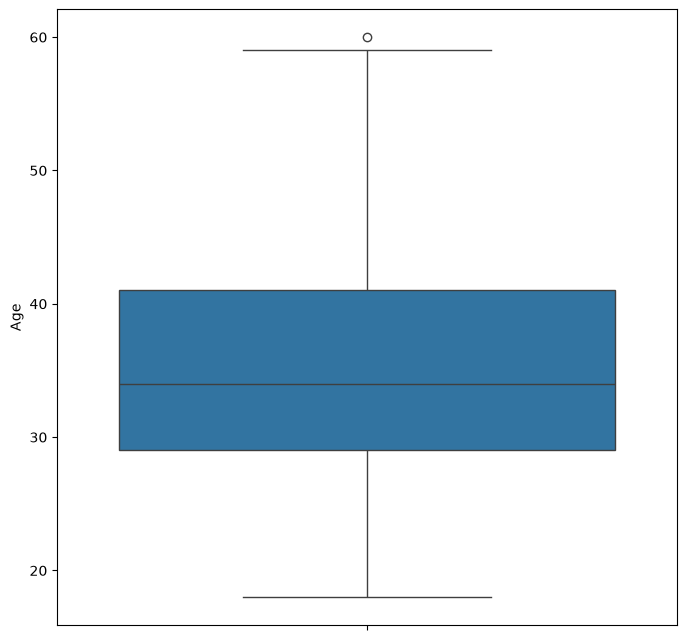

In [517]:
plt.figure(figsize=(8,8))
sns.boxplot(data=df,y='Age')

In [518]:
df[df['Age']==60]

,Age,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,Attrition
320,60.0,2,2,4.0,2,2,1,4,2,7,...,3,2,1,12,3,3,11,7,9,0


In [519]:
df = df[df['Age'] != 60]

<Axes: ylabel='Age'>

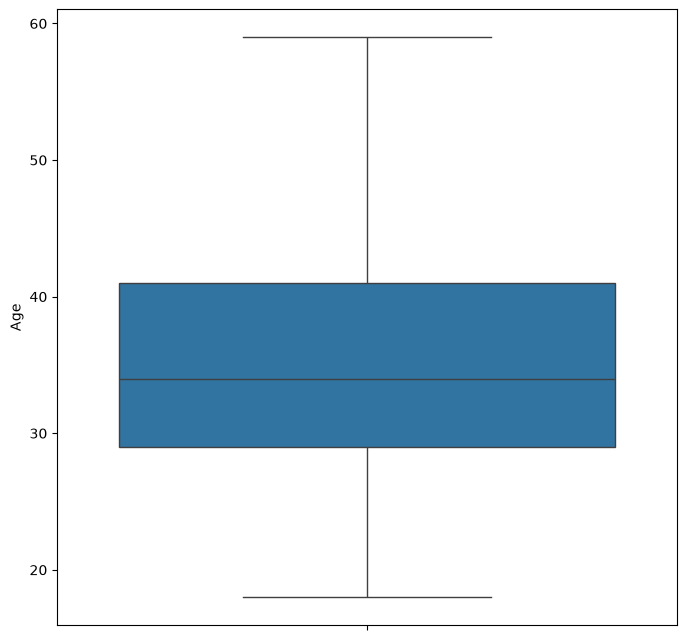

In [520]:
plt.figure(figsize=(8,8))
sns.boxplot(data=df,y='Age')

<Axes: ylabel='TotalWorkingYears'>

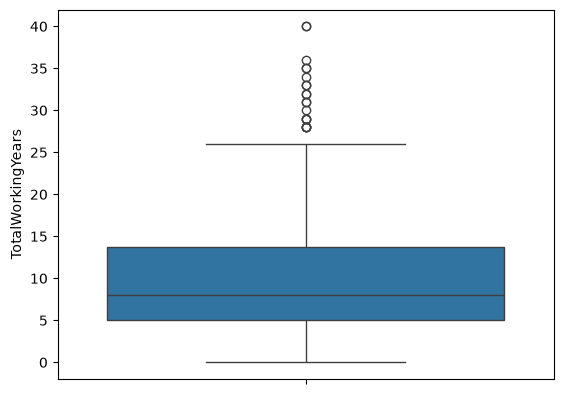

In [521]:
sns.boxplot(data=df,y=df['TotalWorkingYears'])

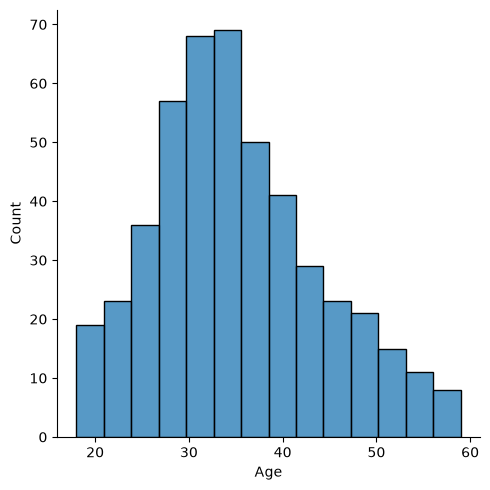

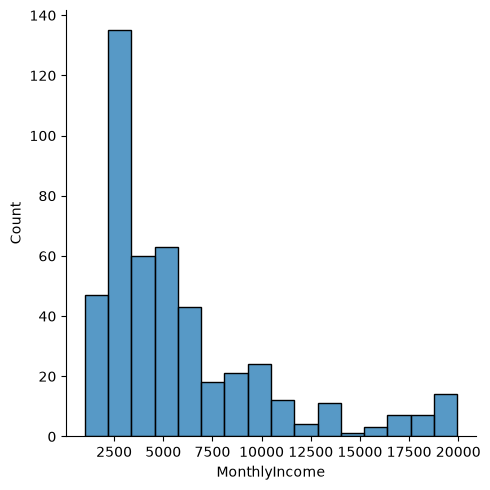

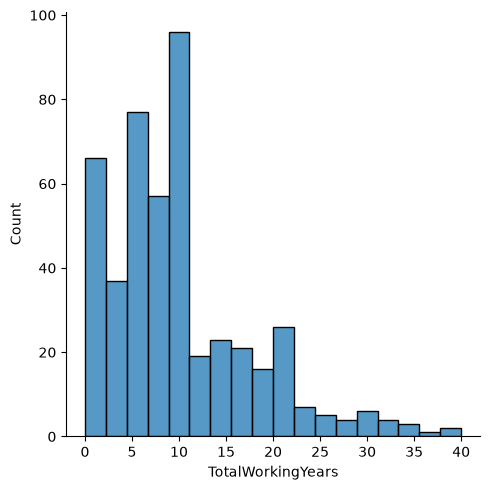

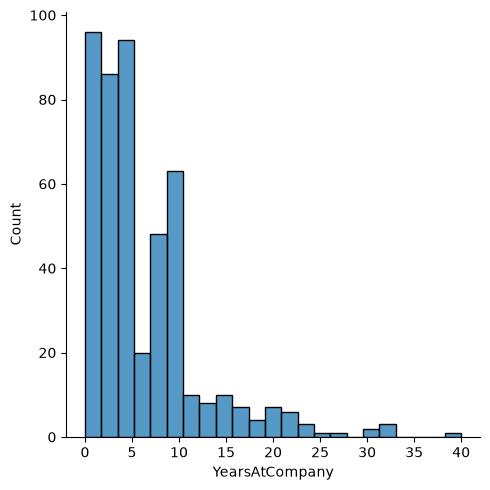

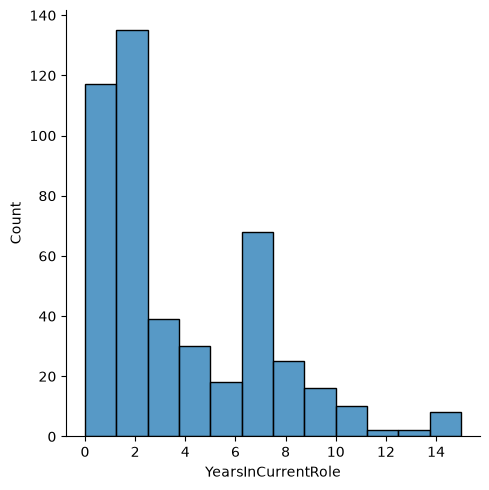

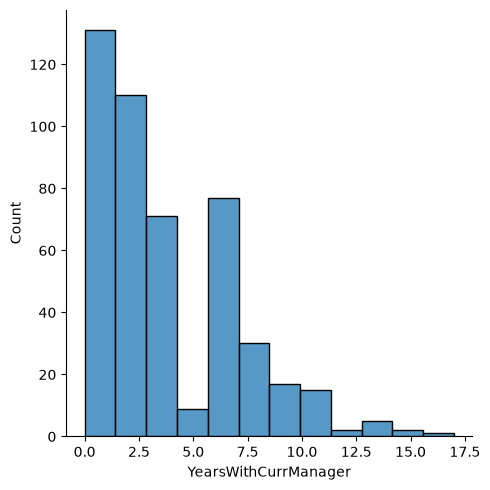

In [522]:
for i in numeric_var:
  sns.displot(df[i])

In [523]:
from scipy.stats import zscore

In [524]:
zscore(df['Age'])

array([ 1.39944156,  1.61806796,  0.30630954, -0.56819607,  0.08768314,
       -0.02163006,  1.61806796, -0.34956966, -1.44270168, -0.78682247,
       -0.02163006,  1.39944156,  0.52493595, -1.66132808,  0.52493595,
        1.72738116, -1.11476207,  2.49257357,  2.60188677,  2.16463397,
       -1.33338847,  0.52493595, -0.78682247, -0.45888286, -1.77064128,
       -0.78682247, -1.66132808, -0.56819607, -0.13094326,  1.29012836,
       -0.24025646, -1.66132808, -0.67750927, -0.56819607,  0.96218875,
        0.63424915,  0.52493595, -0.89613567,  0.19699634,  0.08768314,
       -1.33338847, -0.24025646, -1.77064128, -0.45888286, -0.13094326,
        0.08768314, -1.33338847, -0.78682247, -0.02163006, -1.87995448,
        1.07150195, -0.67750927, -0.45888286, -1.77064128, -1.11476207,
       -1.00544887, -1.33338847,  0.52493595, -1.00544887, -0.67750927,
        0.63424915,  0.74356235,  2.49257357, -0.67750927, -0.78682247,
        1.83669436, -0.56819607,  0.30630954, -0.67750927,  1.61

In [525]:
df = shuffle(df,random_state=42)

In [526]:
df.head()

,Age,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,Attrition
58,26.0,2,1,3.0,1,1,1,1,1,2,...,3,3,0,1,2,2,1,0,1,1
76,44.0,2,1,3.0,1,3,0,4,3,0,...,3,2,1,9,2,3,8,7,7,0
36,30.0,2,2,3.0,1,2,1,2,2,7,...,3,4,1,10,4,3,10,8,7,1
450,39.0,2,2,2.0,3,4,0,3,2,7,...,3,1,0,12,3,2,1,0,0,1
429,33.0,2,1,4.0,1,2,1,3,2,2,...,3,2,1,15,3,3,15,14,7,0


In [527]:
categoric_var = df.select_dtypes(include="object").columns.tolist()


In [528]:
df = pd.get_dummies(df, columns=categoric_var, drop_first=True)

In [529]:
categoric_var

[]

In [530]:
numeric_var

['Age',
 'MonthlyIncome',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsWithCurrManager']

In [531]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [532]:
from sklearn.preprocessing import StandardScaler

In [533]:
scaler = StandardScaler()

In [534]:
numeric_cols = [
    col for col in df.columns
    if col != "Attrition"
    and df[col].dtype != "uint8"
    and df[col].dtype != "bool"
]


In [535]:
from sklearn.model_selection import train_test_split

In [536]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [537]:
numeric_cols = [col for col in numeric_var if col in X_train.columns]

In [538]:

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [539]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(random_state=42,class_weight='balanced')

In [540]:
lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [541]:
y_pred_lr = lr.predict(X_test)

In [542]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7446808510638298

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.70      0.73        47
           1       0.73      0.79      0.76        47

    accuracy                           0.74        94
   macro avg       0.75      0.74      0.74        94
weighted avg       0.75      0.74      0.74        94



In [543]:

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))


Confusion Matrix:

[[33 14]
 [10 37]]


In [544]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm = SVC(kernel='rbf', random_state=42,class_weight='balanced')

In [545]:
svm.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [546]:
y_pred_svm = svm.predict(X_test)

In [547]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.6808510638297872


In [548]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.70      0.64      0.67        47
           1       0.67      0.72      0.69        47

    accuracy                           0.68        94
   macro avg       0.68      0.68      0.68        94
weighted avg       0.68      0.68      0.68        94



In [549]:
print(confusion_matrix(y_test, y_pred_svm))

[[30 17]
 [13 34]]


In [550]:
from xgboost import XGBClassifier

neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos

In [551]:
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

In [552]:
xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [553]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [554]:


results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}


In [555]:

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.7447
SVM: 0.6809
XGBoost: 0.7660


In [556]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
}

In [567]:


grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    param_grid,
    scoring='f1',
    cv=12,
    n_jobs=-1
)

In [568]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",12
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [569]:
print("Best params:", grid.best_params_)


Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [570]:
print("Best CV F1:", grid.best_score_)


Best CV F1: 0.7315256413179757


In [571]:
y_pred_best = grid.predict(X_test)


In [572]:
print("Test accuracy:", accuracy_score(y_test, y_pred_best))

Test accuracy: 0.7340425531914894


In [573]:
print("Test F1:", f1_score(y_test, y_pred_best))

Test F1: 0.7368421052631579


In [574]:
print("Test ROC-AUC:", roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1]))

Test ROC-AUC: 0.8478949751018561


In [ ]:
# Stacking ensemble — combines LogReg, SVM, XGBoost, RandomForest, and adds LightGBM/CatBoost as base learners
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, class_weight='balanced',
    random_state=42, n_jobs=-1
)

In [ ]:

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:

lgbm = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1
)



In [ ]:
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

In [ ]:
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

In [ ]:
cat = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, random_state=42, verbose=0
)

In [ ]:
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

In [ ]:
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

In [ ]:
base_learners = [
    ('lr', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)),
    ('lgbm', lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
]

In [ ]:

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

In [ ]:

stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)


In [ ]:
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))
print("Stacking F1:", f1_score(y_test, y_pred_stack))
print("Stacking ROC-AUC:", roc_auc_score(y_test, stack.predict_proba(X_test)[:, 1]))

In [ ]:

final_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "XGBoost": accuracy_score(y_test, y_pred_xgb),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "LightGBM": accuracy_score(y_test, y_pred_lgbm),
    "CatBoost": accuracy_score(y_test, y_pred_cat),
    "Stacking Ensemble": accuracy_score(y_test, y_pred_stack),
}

In [ ]:
for model, score in sorted(final_results.items(), key=lambda x: -x[1]):
    print(f"{model}: {score:.4f}")